In [1]:
# data read -> no null, no dup -> hypothesis -> chi and anova -> encoding -> feature scaling -> sampling

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('heart_attack_prediction_dataset.csv')

In [4]:
df

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,60,Male,121,94/76,61,1,1,1,0,...,10.806373,235420,19.655895,67,7,7,Thailand,Asia,Northern Hemisphere,0
8759,QSV6764,28,Female,120,157/102,73,1,0,0,1,...,3.833038,217881,23.993866,617,4,9,Canada,North America,Northern Hemisphere,0
8760,XKA5925,47,Male,250,161/75,105,0,1,1,1,...,2.375214,36998,35.406146,527,4,4,Brazil,South America,Southern Hemisphere,1
8761,EPE6801,36,Male,178,119/67,60,1,0,1,0,...,0.029104,209943,27.294020,114,2,8,Brazil,South America,Southern Hemisphere,0


In [5]:
df['Heart Attack Risk'].unique()

array([0, 1])

In [6]:
df.shape

(8763, 26)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [8]:
df.isnull().sum()

Patient ID                         0
Age                                0
Sex                                0
Cholesterol                        0
Blood Pressure                     0
Heart Rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Country                            0
Continent                          0
Hemisphere                         0
Heart Attack Risk                  0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,60,Male,121,94/76,61,1,1,1,0,...,10.806373,235420,19.655895,67,7,7,Thailand,Asia,Northern Hemisphere,0
8759,QSV6764,28,Female,120,157/102,73,1,0,0,1,...,3.833038,217881,23.993866,617,4,9,Canada,North America,Northern Hemisphere,0
8760,XKA5925,47,Male,250,161/75,105,0,1,1,1,...,2.375214,36998,35.406146,527,4,4,Brazil,South America,Southern Hemisphere,1
8761,EPE6801,36,Male,178,119/67,60,1,0,1,0,...,0.029104,209943,27.294020,114,2,8,Brazil,South America,Southern Hemisphere,0


In [11]:
df.columns

Index(['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Blood Pressure',
       'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country',
       'Continent', 'Hemisphere', 'Heart Attack Risk'],
      dtype='object')

In [12]:
df['Country'].unique()

array(['Argentina', 'Canada', 'France', 'Thailand', 'Germany', 'Japan',
       'Brazil', 'South Africa', 'United States', 'Vietnam', 'China',
       'Italy', 'Spain', 'India', 'Nigeria', 'New Zealand', 'South Korea',
       'Australia', 'Colombia', 'United Kingdom'], dtype=object)

In [13]:
df['Continent'].unique()

array(['South America', 'North America', 'Europe', 'Asia', 'Africa',
       'Australia'], dtype=object)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [15]:
df['Heart Attack Risk'].value_counts()

Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64

In [16]:
# chi square - hypo

In [17]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df['Sex'], df['Heart Attack Risk'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')


Heart Attack Risk     0     1
Sex                          
Female             1708   944
Male               3916  2195
Chi2: 0.07, p-value: 0.7906, Degrees of freedom: 1


In [18]:
if p < alpha:
    print('relation')
else:
    print('No relation')

No relation


In [19]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df['Diet'], df['Heart Attack Risk'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')


Heart Attack Risk     0     1
Diet                         
Average            1886  1026
Healthy            1881  1079
Unhealthy          1857  1034
Chi2: 0.95, p-value: 0.6204, Degrees of freedom: 2


In [20]:
if p < alpha:
    print('relation')
else:
    print('No relation')

No relation


In [21]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df['Country'], df['Heart Attack Risk'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')

Heart Attack Risk    0    1
Country                    
Argentina          297  174
Australia          281  168
Brazil             299  163
Canada             282  158
China              281  155
Colombia           267  162
France             289  157
Germany            305  172
India              283  129
Italy              295  136
Japan              289  144
New Zealand        284  151
Nigeria            270  178
South Africa       281  144
South Korea        246  163
Spain              280  150
Thailand           267  161
United Kingdom     297  160
United States      254  166
Vietnam            277  148
Chi2: 20.30, p-value: 0.3767, Degrees of freedom: 19


In [22]:
if p < alpha:
    print('relation')
else:
    print('No relation')

No relation


In [23]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df['Continent'], df['Heart Attack Risk'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')


Heart Attack Risk     0    1
Continent                   
Africa              551  322
Asia               1643  900
Australia           565  319
Europe             1466  775
North America       536  324
South America       863  499
Chi2: 3.83, p-value: 0.5734, Degrees of freedom: 5


In [24]:
if p < alpha:
    print('relation')
else:
    print('No relation')

No relation


In [25]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df['Hemisphere'], df['Heart Attack Risk'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')


Heart Attack Risk       0     1
Hemisphere                     
Northern Hemisphere  3607  2053
Southern Hemisphere  2017  1086
Chi2: 1.36, p-value: 0.2436, Degrees of freedom: 1


In [26]:
if p < alpha:
    print('relation')
else:
    print('No relation')

No relation


In [27]:
df.drop(columns='Sex', inplace = True)
df.drop(columns='Diet', inplace = True)
df.drop(columns='Country', inplace = True)
df.drop(columns='Continent', inplace = True)
df.drop(columns='Hemisphere', inplace = True)

In [28]:
df.columns

Index(['Patient ID', 'Age', 'Cholesterol', 'Blood Pressure', 'Heart Rate',
       'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Exercise Hours Per Week',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day',
       'Heart Attack Risk'],
      dtype='object')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Cholesterol                      8763 non-null   int64  
 3   Blood Pressure                   8763 non-null   object 
 4   Heart Rate                       8763 non-null   int64  
 5   Diabetes                         8763 non-null   int64  
 6   Family History                   8763 non-null   int64  
 7   Smoking                          8763 non-null   int64  
 8   Obesity                          8763 non-null   int64  
 9   Alcohol Consumption              8763 non-null   int64  
 10  Exercise Hours Per Week          8763 non-null   float64
 11  Previous Heart Problems          8763 non-null   int64  
 12  Medication Use      

In [30]:
df

,Patient ID,Age,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
0,BMW7812,67,208,158/88,72,0,0,1,0,0,...,0,0,9,6.615001,261404,31.251233,286,0,6,0
1,CZE1114,21,389,165/93,98,1,1,1,1,1,...,1,0,1,4.963459,285768,27.194973,235,1,7,0
2,BNI9906,21,324,174/99,72,1,0,0,0,0,...,1,1,9,9.463426,235282,28.176571,587,4,4,0
3,JLN3497,84,383,163/100,73,1,1,1,0,1,...,1,0,9,7.648981,125640,36.464704,378,3,4,0
4,GFO8847,66,318,91/88,93,1,1,1,1,0,...,1,0,6,1.514821,160555,21.809144,231,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,60,121,94/76,61,1,1,1,0,1,...,1,1,8,10.806373,235420,19.655895,67,7,7,0
8759,QSV6764,28,120,157/102,73,1,0,0,1,0,...,0,0,8,3.833038,217881,23.993866,617,4,9,0
8760,XKA5925,47,250,161/75,105,0,1,1,1,1,...,1,0,5,2.375214,36998,35.406146,527,4,4,1
8761,EPE6801,36,178,119/67,60,1,0,1,0,0,...,1,1,5,0.029104,209943,27.294020,114,2,8,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Cholesterol                      8763 non-null   int64  
 3   Blood Pressure                   8763 non-null   object 
 4   Heart Rate                       8763 non-null   int64  
 5   Diabetes                         8763 non-null   int64  
 6   Family History                   8763 non-null   int64  
 7   Smoking                          8763 non-null   int64  
 8   Obesity                          8763 non-null   int64  
 9   Alcohol Consumption              8763 non-null   int64  
 10  Exercise Hours Per Week          8763 non-null   float64
 11  Previous Heart Problems          8763 non-null   int64  
 12  Medication Use      

In [32]:
df = df.rename(columns={
    'Heart Attack Risk': 'Heart_Attack_Risk',
    'Heart Rate': 'Heart_Rate',
    'Family History': 'Family_History',
    'Alcohol Consumption': 'Alcohol_Consumption',
    'Exercise Hours Per Week': 'Exercise_Hours_Per_Week',
    'Previous Heart Problems': 'Previous_Heart_Problems',
    'Medication Use': 'Medication_Use',
    'Stress Level': 'Stress_Level',
    'Sedentary Hours Per Day': 'Sedentary_Hours_Per_Day',
    'Physical Activity Days Per Week': 'Physical_Activity_Days_Per_Week',
    'Sleep Hours Per Day': 'Sleep_Hours_Per_Day'
})

In [33]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import _get_covariance, anova_lm

formula = 'Heart_Attack_Risk ~ Age + Cholesterol + Heart_Rate + Diabetes + Family_History + Smoking + Obesity + Alcohol_Consumption + Exercise_Hours_Per_Week + Previous_Heart_Problems + Medication_Use + Stress_Level + Sedentary_Hours_Per_Day + Income + BMI + Triglycerides + Physical_Activity_Days_Per_Week + Sleep_Hours_Per_Day'

model = ols(formula, df).fit()
aov_table = anova_lm(model)
print(aov_table)
print(aov_table['PR(>F)'])

                                     df       sum_sq   mean_sq         F  \
Age                                 1.0     0.082599  0.082599  0.359194   
Cholesterol                         1.0     0.758112  0.758112  3.296754   
Heart_Rate                          1.0     0.036082  0.036082  0.156906   
Diabetes                            1.0     0.624800  0.624800  2.717026   
Family_History                      1.0     0.002436  0.002436  0.010595   
Smoking                             1.0     0.120955  0.120955  0.525990   
Obesity                             1.0     0.344880  0.344880  1.499759   
Alcohol_Consumption                 1.0     0.386908  0.386908  1.682524   
Exercise_Hours_Per_Week             1.0     0.233650  0.233650  1.016059   
Previous_Heart_Problems             1.0     0.000489  0.000489  0.002127   
Medication_Use                      1.0     0.010466  0.010466  0.045512   
Stress_Level                        1.0     0.028874  0.028874  0.125563   
Sedentary_Ho

In [34]:
print(aov_table['PR(>F)'])

Age                                0.548970
Cholesterol                        0.069451
Heart_Rate                         0.692031
Diabetes                           0.099319
Family_History                     0.918020
Smoking                            0.468317
Obesity                            0.220741
Alcohol_Consumption                0.194624
Exercise_Hours_Per_Week            0.313483
Previous_Heart_Problems            0.963216
Medication_Use                     0.831071
Stress_Level                       0.723087
Sedentary_Hours_Per_Day            0.542005
Income                             0.367813
BMI                                0.980226
Triglycerides                      0.329752
Physical_Activity_Days_Per_Week    0.623799
Sleep_Hours_Per_Day                0.091410
Residual                                NaN
Name: PR(>F), dtype: float64


In [35]:
df.drop(['Age', 'Cholesterol', 'Heart_Rate', 'Diabetes', 'Family_History', 'Smoking', 'Obesity', 'Alcohol_Consumption', 'Exercise_Hours_Per_Week', 'Previous_Heart_Problems', 'Medication_Use', 'Stress_Level', 'Sedentary_Hours_Per_Day', 'Income', 'BMI', 'Triglycerides', 'Physical_Activity_Days_Per_Week', 'Sleep_Hours_Per_Day'], axis=1, inplace=True)

In [36]:
df.columns

Index(['Patient ID', 'Blood Pressure', 'Heart_Attack_Risk'], dtype='object')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Patient ID         8763 non-null   object
 1   Blood Pressure     8763 non-null   object
 2   Heart_Attack_Risk  8763 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 205.5+ KB


In [38]:
df.drop(columns='Patient ID', inplace=True)

In [39]:
df

,Blood Pressure,Heart_Attack_Risk
0,158/88,0
1,165/93,0
2,174/99,0
3,163/100,0
4,91/88,0
...,...,...
8758,94/76,0
8759,157/102,0
8760,161/75,1
8761,119/67,0


In [40]:
from sklearn.preprocessing import OrdinalEncoder
o = OrdinalEncoder()

df[['Blood Pressure']] = o.fit_transform(df[['Blood Pressure']])

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Blood Pressure     8763 non-null   float64
 1   Heart_Attack_Risk  8763 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 137.1 KB


In [42]:
x = df.drop('Heart_Attack_Risk', axis=1)
y = df['Heart_Attack_Risk']

In [43]:
y.unique()

array([0, 1])

In [44]:
# feature scaling

In [45]:
df['Heart_Attack_Risk'].unique()

array([0, 1])

In [46]:
# sampling -> binary label

In [47]:
df['Heart_Attack_Risk'].value_counts()

Heart_Attack_Risk
0    5624
1    3139
Name: count, dtype: int64

<Axes: xlabel='Heart_Attack_Risk', ylabel='count'>

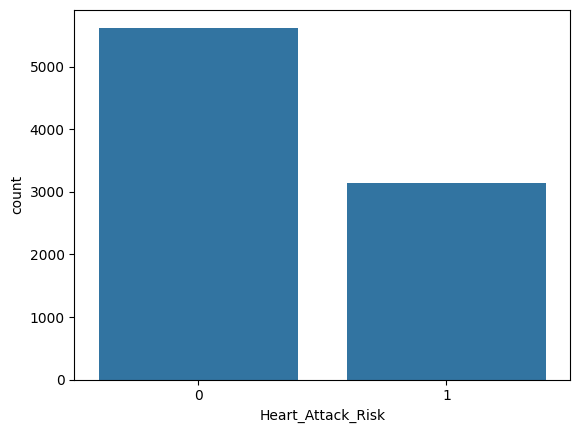

In [48]:
import seaborn as sns
sns.countplot(x='Heart_Attack_Risk', data=df)

In [49]:
#from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler                      #file
                                                                             #prefernce                                                                            # settings                                                                            #env(search)                                                                            #windows option click                                                                            #open("SCIPY_ARRAY_API":"1")
x=df.drop(columns="Heart_Attack_Risk",axis=1)
y=df["Heart_Attack_Risk"]
#smote=SMOTE(sampling_strategy="minority")
underSamp= RandomUnderSampler(sampling_strategy="majority")                   #pip install imbalanced-learn scikit-learn -y
x_samp,y_samp=underSamp.fit_resample(x,y)                                          ##reinstall with compatible version

                                                                           #pip install scikit-learn==1.3.2 imbalanced-learn==0.1                                                                       # reinstall kernal
                                                                           #from imblearn.over_sampling import SMOT                                                                          #print(imblearn._version_)
print(x_samp.shape)
print(y_samp.shape)

(6278, 1)
(6278,)


In [50]:
y_samp.value_counts()

Heart_Attack_Risk
0    3139
1    3139
Name: count, dtype: int64

In [51]:
x_samp = df.drop(columns= 'Heart_Attack_Risk')
y_samp = df['Heart_Attack_Risk']

In [52]:
x_samp

,Blood Pressure
0,2510.0
1,2815.0
2,3224.0
3,2689.0
4,3563.0
...,...
8758,3680.0
8759,2434.0
8760,2624.0
8761,838.0


In [53]:
from sklearn.preprocessing import MinMaxScaler  
mm=MinMaxScaler()
c=mm.fit_transform(x_samp)
print(c)


[[0.64128769]
 [0.71921308]
 [0.82370976]
 ...
 [0.6704139 ]
 [0.21410322]
 [0.41824221]]


In [54]:
df.shape

(8763, 2)

In [55]:
# Training and evaluation for classification 

In [ ]:
from sklearn.model_selection import train_test_split
x_samp_train,x_samp_test,y_samp_train,y_samp_test=train_test_split(x_samp,y_samp, test_size=0.20,random_state=42)
print(x_samp_train.shape)
print(x_samp_test.shape)
print(y_samp_train.shape)
print(y_samp_test.shape)

from sklearn.linear_model import LogisticRegression  
lr=LogisticRegression()
lr.fit(x_samp_train,y_samp_train)
y_pred=lr.predict(x_samp_train)
y_pred

(7010, 1)
(1753, 1)
(7010,)
(1753,)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


array([0, 0, 0, ..., 0, 0, 0], shape=(7010,))

In [57]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report  
print(accuracy_score(y_samp_train,y_pred))
print(confusion_matrix(y_samp_train,y_pred))
print(classification_report(y_samp_train,y_pred))

0.6417974322396577
[[4499    0]
 [2511    0]]
              precision    recall  f1-score   support

           0       0.64      1.00      0.78      4499
           1       0.00      0.00      0.00      2511

    accuracy                           0.64      7010
   macro avg       0.32      0.50      0.39      7010
weighted avg       0.41      0.64      0.50      7010



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  